In [3]:
import math
import pygrib
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import matplotlib.path as mpath
import cartopy.crs as ccrs
import datetime
import sys
#
import metpy.calc as mpcalc
from metpy.units import units
#from scipy.ndimage.filters import maximum_filter, minimum_filter
#
import argparse

In [11]:
# GSMの読み込む初期値の年月日時をUTCで与えます。
i_year =2021
i_month = 10
i_day = 1
i_hourZ = 0
#
# 予想時間を与える。この値は注意が必要です。下3桁目が日数、下２桁で時間で与えます。
#  初期値なら0、18時間後なら18、24時間後なら100、36時間後なら112となります。
i_ft = 0
#
#  時間に変換
ft_hours=int(i_ft/100) * 24 + int(i_ft%100)
#
# Jetを解析する気圧面を指定
tagHp = 300
#
# 描画する範囲の大まかな指定
i_area = [115, 151, 20, 50]  # 日本付近
str_area = "jp"   # ファイル名に利用
#
## GPVの切り出し領域の指定：(lonW,latS)-(lonE,latN)の矩形                                                                                                      
latS=-20
latN=80
lonW=70
lonE=190
#
# データの格納先フォルダー名
##!!! GRIB2データの保存先をFolderを指定すること !!!
data_fld="./data/gsm/"
#
####################################################
#
# 読み込むGRIB2形式GSMのファイル名
gsm_fn_t="Z__C_RJTD_{0:4d}{1:02d}{2:02d}{3:02d}0000_GSM_GPV_Rgl_FD{4:04d}_grib2.bin"
gr_fn= gsm_fn_t.format(i_year,i_month,i_day,i_hourZ,i_ft)
#
# データOpen
grbs = pygrib.open(data_fld + gr_fn)
#
# データ取得                                                                                                                       
grbHt = grbs(shortName="gh",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbWu = grbs(shortName="u",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbWv = grbs(shortName="v",typeOfLevel='isobaricInhPa',level=tagHp)[0]
#
# データClose
grbs.close()
#
print(gr_fn)
#
## データ切り出し                                                                                                                   
valHt, latHt, lonHt = grbHt.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valWu, latWu, lonWu = grbWu.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valWv, latWv, lonWv = grbWv.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)

Z__C_RJTD_20211001000000_GSM_GPV_Rgl_FD0000_grib2.bin


In [12]:
## 非地衡風算出のためにxarrayデータセットを作成                                                                                   
ds = xr.Dataset(
   {
       "Geopotential_height": (["lat", "lon"], valHt),                                                                        
       "u_wind": (["lat", "lon"], valWu),
       "v_wind": (["lat", "lon"], valWv),
   },
   coords={
       "level": [tagHp],
       "lat": latHt[:,0],
       "lon": lonHt[0,:],
       "time": [grbHt.validDate],
   },
)
# 単位も入力する
ds['Geopotential_height'].attrs['units'] = 'm'
ds['u_wind'].attrs['units']='m/s'
ds['v_wind'].attrs['units']='m/s'
ds['level'].attrs['units'] = 'hPa'
ds['lat'].attrs['units'] = 'degrees_north'
ds['lon'].attrs['units'] = 'degrees_east'
#
# metpy仕様に変換
dsp= ds.metpy.parse_cf()
#
# 風速
dsp['wind_speed'] = mpcalc.wind_speed(dsp['u_wind'],dsp['v_wind'])
#  
# 地衡風計算　平均処理した高度から求める
dsp['uag'], dsp['vag'] = mpcalc.ageostrophic_wind(dsp['Geopotential_height'],dsp['u_wind'],dsp['v_wind'])
#
# 収束発散                                                                               
dsp['conv'] = mpcalc.divergence(dsp['u_wind'],dsp['v_wind'])
#
# knotsへ変換
dsp['wind_speed'] = (dsp['wind_speed']).metpy.convert_units('knots')
dsp['uag'] = (dsp['uag']).metpy.convert_units('knots')
dsp['vag'] = (dsp['vag']).metpy.convert_units('knots')

Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
/Users/rkurora/opt/anaconda3/envs/met_env/lib/python3.8/site-packages/pint/quantity.py:1237: RuntimeWarning: divide by zero encountered in true_divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)
/Users/rkurora/opt/anaconda3/envs/met_env/lib/python3.8/site-packages/pint/quantity.py:1237: RuntimeWarning: invalid value encountered in multiply
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


In [13]:
####  作図用処理                                                                                                      
## 年月日                                                                                                    
dt_v = grbHt.validDate
dt_i = grbHt.analDate
dt_str = (dt_i.strftime("%H00UTC%d%b%Y")).upper()
dt_str2 = dt_i.strftime("%Y%m%d%H")
#
# 発散のハッチの指定
levels_reld = [-10, -5, -2, -1, 1, 2, 5, 10]
#
# ISOTACの等値線の指定
levels_ws =np.arange(40,300,20)
#
# 高度の等値線の指定
clevs_hght = np.arange(0, 8000, 30)
#
# 等高度線 等値線の間隔を指定 30/60/120m単位                                    
if (tagHp < 400):
  dd_hgt = 120
elif (tagHp < 700):
  dd_hgt = 60
else:
  dd_hgt = 30
#
# 緯線・経線の指定
dlon,dlat=10,10   # 10度ごとに
#

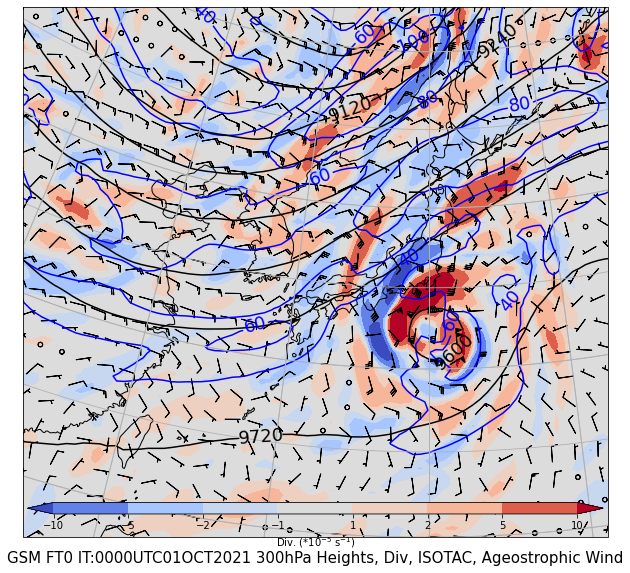

In [14]:
## 図法指定                                                                             
proj = ccrs.Stereographic(central_latitude=60, central_longitude=140)
latlon_proj = ccrs.PlateCarree()
## 図のSIZE指定inch                                                                        
fig = plt.figure(figsize=(10,8))
## 余白設定                                                                                
plt.subplots_adjust(left=0, right=1, bottom=0.06, top=0.98)                  
## 作図                                                                                    
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent(i_area, latlon_proj)
#
## 海岸線
ax.coastlines(resolution='50m',) # 海岸線の解像度を上げる                                                    
ax.gridlines()
#
## グリッド線                                                                                                 
xticks=np.arange(0,360.1,dlon)
yticks=np.arange(-90,90.1,dlat)
gl = ax.gridlines(crs=ccrs.PlateCarree()
         , draw_labels=False
         , linewidth=1, alpha=0.8)
gl.xlocator = mticker.FixedLocator(xticks)
gl.ylocator = mticker.FixedLocator(yticks)
#
# 発散のシェード
cn_reld = ax.contourf(dsp['lon'], dsp['lat'], dsp['conv'].values * 1e5,
                    levels_reld , cmap="coolwarm", extend='both',
                    transform=latlon_proj )
# 発散のカラーバーの表示
#  add_axes([左端の距離, 下端からの距離, 横幅, 縦幅])                                    
ax_reld = fig.add_axes([0.1, 0.1, 0.8, 0.02])
cb_reld = fig.colorbar(cn_reld, orientation='horizontal', shrink=0.74,
                       aspect=40, pad=0.01, cax=ax_reld)
cb_reld.set_label('Div. (*10$^{-5}$ s$^{-1}$)')
#
# 等風速線                                                                               
cn_ws = ax.contour(dsp['lon'], dsp['lat'], dsp['wind_speed'].values,
                    colors='blue', linewidths=1.5,
                    levels=levels_ws, transform=latlon_proj )
ax.clabel(cn_ws, fontsize=18, inline=True, colors='blue',
          inline_spacing=5, fmt='%i', rightside_up=True)
#
# 等高度線
dataHgt = dsp['Geopotential_height']
min_hgt = int(dataHgt.min() / dd_hgt) * dd_hgt
max_hgt = dataHgt.max() + dd_hgt
levels_hgt =np.arange(min_hgt, max_hgt, dd_hgt)
cn_hgt = ax.contour(dsp['lon'], dsp['lat'], dsp['Geopotential_height'], colors='black',
                    linewidths=1.5, levels=levels_hgt, transform=latlon_proj )
ax.clabel(cn_hgt, levels_hgt, fontsize=18, inline=True, colors='black',
          inline_spacing=5, fmt='%i', rightside_up=True)
#                                                                                                            
# 非地衡風 矢羽:データを間引いて描画                                                          
wind_slice2 = (slice(None, None, 3), slice(None, None, 3))
wind_slice0 = slice(None, None, 3)                        
ax.barbs(dsp['lon'][wind_slice0], dsp['lat'][wind_slice0],
         dsp['uag'].values[wind_slice2], dsp['vag'].values[wind_slice2], length=5.5,
         pivot='middle', color='black', transform=latlon_proj)
#
## Caption
fig.text(0.5,0.01,"GSM FT{0:d} IT:".format(ft_hours)+dt_str+
         " {0}hPa Heights, Div, ISOTAC, Ageostrophic Wind".format(tagHp) ,
         ha='center',va='bottom', size=15)
plt.show()

In [15]:
## 出力                                                                                    
output_fig_nm="gsm_{0}UTC_FT{1:03d}_jet{2}{3}.png".format(dt_str2,ft_hours,tagHp,str_area)
plt.savefig(output_fig_nm)
print("output:{}".format(output_fig_nm))

output:gsm_2021100100UTC_FT000_jet300jp.png


<Figure size 432x288 with 0 Axes>